In [3]:
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
import sqlite3

In [4]:
load_dotenv()
model = ChatGroq(
    model="openai/gpt-oss-120b"
)


In [5]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

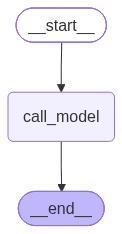

In [7]:
graph = builder.compile()
graph

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Sumran."}]})

{'messages': [HumanMessage(content='Hi! My name is Sumran.', additional_kwargs={}, response_metadata={}, id='c8d9e42d-84de-478f-ae26-6ea91d1ba771'),
  AIMessage(content='Hello Sumran! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Sumran." Probably wants a greeting. Should respond politely. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 79, 'total_tokens': 130, 'completion_time': 0.11226971, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.004119434, 'prompt_tokens_details': None, 'queue_time': 0.376060953, 'total_time': 0.116389144}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0435a-8d39-7e83-ba38-82d5fc92e5c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_token

In [9]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='25dbba8c-e148-48bd-9a9c-f7fded483ab1'),
  AIMessage(content='I don’t have that information. Could you let me know your name?', additional_kwargs={'reasoning_content': 'We have a conversation. The user asks: "What is my name?" There\'s no prior context giving the name. According to policy, we must not guess personal info. We should respond that we don\'t know the name. Possibly ask user to provide it. We should be concise.'}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 76, 'total_tokens': 157, 'completion_time': 0.170470725, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.015369706, 'prompt_tokens_details': None, 'queue_time': 0.429063932, 'total_time': 0.185840431}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_dc4ca88fa4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider':

In [10]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver() #stores in ram aftere restarting it will again forget and nothng is stored then in the memory because ram is volatile therefore we make use of database
graph = builder.compile(checkpointer=checkpointer)

In [13]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Sumran."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Sumran.', additional_kwargs={}, response_metadata={}, id='65bd42ce-ee30-4c94-a0cf-4cc1fb6b8abc'),
  AIMessage(content='Hi Sumran! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Sumran." Probably they want a greeting. We should respond friendly, ask how can help. Follow policies. No issues.'}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 79, 'total_tokens': 139, 'completion_time': 0.128166377, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003216957, 'prompt_tokens_details': None, 'queue_time': 0.37496105, 'total_time': 0.131383334}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0435c-f746-7142-94d5-87d3b37f222f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'

In [16]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)
#here we startd a new converstaion by passing the new thread therefore  it dont remember my name because stm is applied here only 

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='a670c522-7492-4a75-905d-cb6139b3a110'),
  AIMessage(content='I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" There\'s no prior context. According to policy, we must not fabricate personal data. We must respond that we don\'t know the user\'s name. We can ask them to provide it if needed.'}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 76, 'total_tokens': 159, 'completion_time': 0.175414173, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.00472594, 'prompt_tokens_details': None, 'queue_time': 0.286297728, 'total_time': 0.180140113}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_49bfac06f1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider'

In [17]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Sumran.
- AIMessage : Hi Sumran! Nice to meet you. How can I help you today?
